# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())

print("\nProporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())

print("\nProporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario** Se utilizaron 2 tablas para analizar los valores nulos (users y usage), en las cuales se evidenciaron datos nulos en ambas tablas.
💡 **Nota:**
Valores nulos:
Tabla user: esta tabla consta de 8 columnas (user_id, first_name, last_name, age, city, reg_date, Plan, churn_rate), las columnas que presentan datos nulos son: city con 469 datos nulos que equivalen al 11.7% y churn_rate con 3534 datos nulos que equivale al 88.3%, se puede inferir que en la columna city a la hora del registro de un usuario no es requisito llenar ese campo, cabe resaltar que si se es mas estricto con ese campo mejoraria este porcentaje (al menos bajarlo a un digito). en cuanto al churn_rate esta elevado 88.3% es una buena noticia por que solo el 11.7% de los usuarios han termnado su contrato que equivale al 468.

Tabla Usage: esta tabla consta de 6 columnas (id, user_id, type, date, duration y lenght), las columnas que presentan datos nulos son: date con 50 datos nulos que equivalen al 1.25%, duration con 22076 datos nulos que equivalen al 55.1% y length con 17896 datos nulos que equivalen al 44.7%. analizando las columnas con datos nulos (date, duration y length) se puede inferir en la columna date puede haber un porblema de digitacion puesto que el porcentaje de datos nulos es muy bajo (1,25) y esta columna no es relevante para el analisis, en cuanto a duration y length que tienen valores elevados (55.1% y 44.7%), al analizar el dataset se puede evidenciar que la columna duration el valor es nulo cuando cuando la columna type es text y la columna leght tiene el mismo comportamiento cuando la columna es call, se omitiran los valores nulos de estas dos columnas para caer en errores de anlisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` se puede observar que la cantidad total de users son 4000 y las otras metricas (mean, min, max) son irrelevantes para el analisis.
- La columna `age` se puede observar un error en el valor minimo (-999)

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` se puede observar que la cantidad total de de eventos por usuario y las otras metricas (mean, min, max) son irrelevantes para el analisis.
- Las columnas de duration y length se puede observar la cantidad total de duracion de las llamadas y el total de los mensajes de texto.

In [43]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"Valores únicos en la columna {col}:")
    print(users[col].unique())
    print("-" * 30)

Valores únicos en la columna city:
['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
------------------------------
Valores únicos en la columna plan:
['Basico' 'Premium']
------------------------------


- La columna `city` se puede observar 6 ciudades (Medellin, CDMX, Bogota, Gdl, MTY y cali), ademas de 2 datos nulos (NA y nan)
- La columna `plan` se puede observar 2 tipos de planes "Basico" y "Premium"

In [44]:
# explorar columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` existen 2 tipos de servicios "call" y "text"


---
✍️ **Comentario**: en esta parte del analisis se analizo el dataset para encontrar datos nulos y sentinels, se encontraron en 2 columnas (city y age) 

**Valores inválidos o sentinels**  
- para la columna age se cambiara los sentinels por la mediana
-  para la columna city se cambiaria los sentinels por valores nulos

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
# Use .dt.year para extraer el año y .value_counts() para ver cuántas veces aparece cada uno
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date` se puede observar un error en la fecha, se encuentan 40 registros con una fecha de 2026 sabiendo que este dataset solo tiene informacion hasta el 2024

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, se encuentran 39950 registros del año 2024.

✍️ **Comentario**: al filtrar la informacion de reg_date y usage, se puede observar en la columna reg_date errores en el registro con 40 de ellos fuera de los años de la muestra del data set (2026), en cuanto a fecha no tiene ningun error.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age

# Calculamos la mediana filtrando los valores imposibles
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios (puedes usar unique para ver que ya no está el "?")
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios viendo la distribución de años (incluyendo los nulos)
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [49]:
# Verificación MAR en usage (Missing At Random) para duration
# filtre las filas donde duration es nulo y contamos los valores de la columna 'type'
usage[usage['duration'].isna()]['type'].value_counts()

text    22076
Name: type, dtype: int64

In [48]:
# Verificación MAR en usage (Missing At Random) para length
# filtre las filas donde length es nulo y contamos los valores de la columna 'type'
usage[usage['length'].isna()]['type'].value_counts()


call    17896
Name: type, dtype: int64

Al verificar los datos, se observa que los valores nulos en duration ocurren exclusivamente cuando el type es un mensaje de texto ('text'). De la misma manera, los nulos en la columna length se presentan únicamente cuando el type es una llamada ('call'). Como la ausencia de estos datos depende de otra variable observable (type), confirmamos que son nulos de tipo MAR (Missing At Random). Recomiendo dejarlos como nulos, ya que lógicamente un mensaje no tiene duración en minutos y una llamada no tiene longitud de caracteres."

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [45]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
# Use groupby por 'user_id' y sumamos las columnas auxiliares más la duración
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [46]:
# Renombrar columnas
# cambie los nombres según las instrucciones del ejercicio
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [47]:
# Combinar la tabla agregada con el dataset de usuarios
# use un merge tipo 'left' para mantener a todos los usuarios, incluso si no tuvieron consumo
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
(user_profile['plan'].value_counts(normalize=True) * 100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

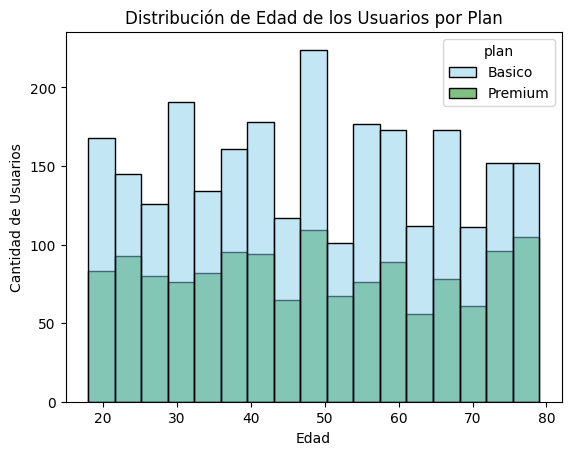

In [50]:
# Histograma para visualizar la edad (age)
# use data=user_profile, definimos 'age' en el eje x, y separamos por 'plan'
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])

# Agregar título y etiquetas
plt.title('Distribución de Edad de los Usuarios por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()

💡Insights: 
Distribución general: El histograma muestra la distribución de edades de los usuarios, la cual abarca un rango continuo desde aproximadamente los 18 hasta los 80 años. La forma de la distribución es relativamente uniforme o plana, sin un sesgo drástico hacia la izquierda o la derecha. Esto indica que la base de clientes está distribuida de manera equilibrada en todas las etapas de la vida adulta.

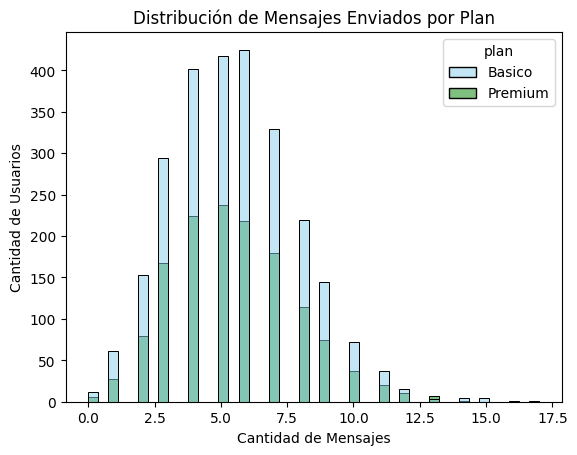

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Mensajes Enviados por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución general: El histograma muestra una clara distribución sesgada a la derecha (asimétrica positiva). Esto indica que la gran mayoría de los usuarios se concentra en el extremo inferior (enviando pocos mensajes), mientras que la frecuencia cae rápidamente a medida que aumenta la cantidad de mensajes.

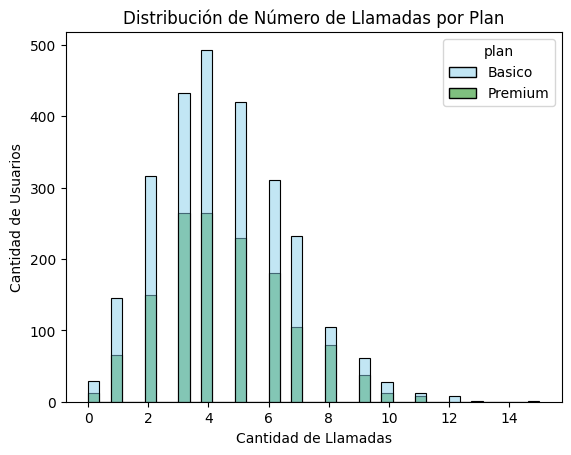

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Número de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución general: La gráfica muestra una distribución sesgada a la derecha (asimétrica positiva) en cuanto a la cantidad de llamadas realizadas por los usuarios. La gran mayoría de los clientes efectúa un número reducido o moderado de llamadas, y la frecuencia disminuye progresivamente hacia los extremos superiores.

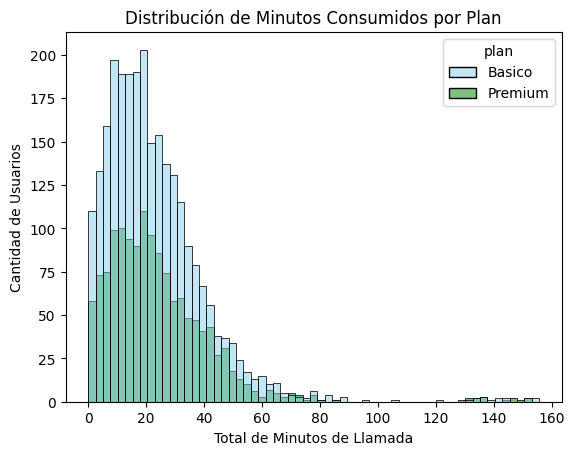

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Minutos Consumidos por Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
-Distribución general: La gráfica muestra una distribución fuertemente sesgada a la derecha (asimétrica positiva) en cuanto al total de minutos consumidos. La gran mayoría de los clientes se concentra en los niveles más bajos de consumo de tiempo, y la cantidad de usuarios disminuye progresivamente a medida que aumentan los minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

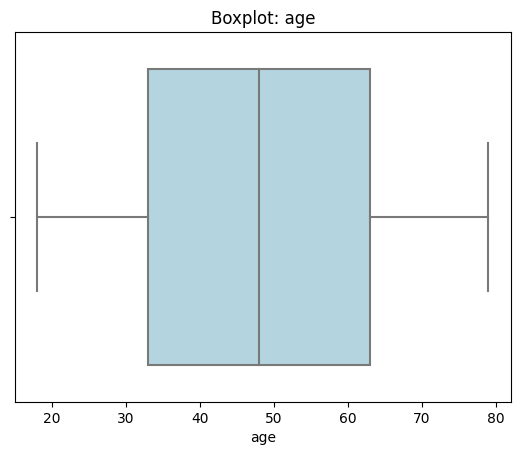

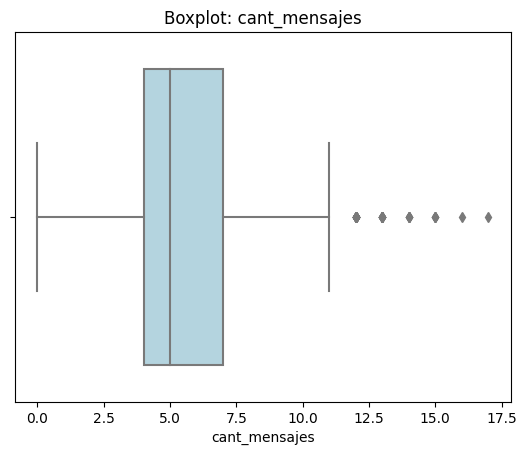

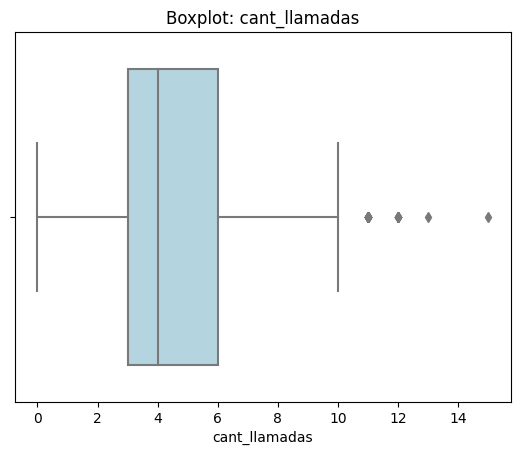

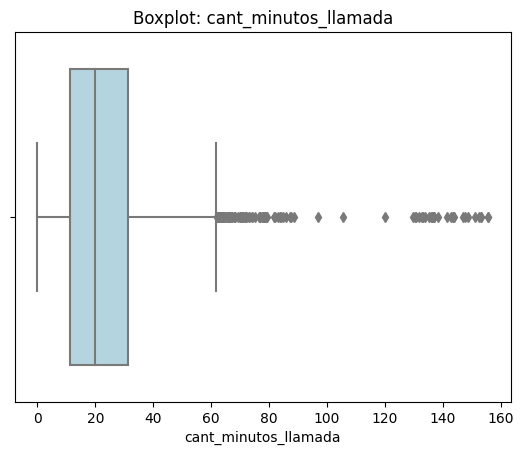

In [34]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    # Usamos seaborn para crear el boxplot
    sns.boxplot(data=user_profile, x=col, color='lightblue')
    # Aplicamos el hint de las instrucciones para el título
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers. Toda la distribución de edades se encuentra contenida de forma simétrica dentro de los límites ("bigotes") del gráfico, abarcando desde los 18 hasta los 80 años sin ningún punto aislado.
- cant_mensajes: Sí presenta outliers superiores. Se observan varios puntos individuales más allá del límite superior del bigote (que corta aproximadamente en 11), lo que indica la existencia de usuarios con un comportamiento atípico que envían entre 12 y 17 mensajes.
- cant_llamadas: Sí presenta outliers superiores. El gráfico expone puntos individuales más allá del límite derecho (ubicado en 10 llamadas), representando a un grupo minoritario de clientes que efectúan un volumen atípico de 11, 12, 13 y 15 llamadas.
- cant_minutos_llamada: Sí presenta outliers superiores (en gran cantidad). Se observa una cola muy densa de puntos atípicos por encima de la marca de los 60 minutos, la cual se extiende hasta casi los 160 minutos. Como justificamos en un paso anterior, estos representan a los heavy users (usuarios de alto consumo) de la red y deben mantenerse en el análisis.

In [35]:
# Calcular límites usando el método IQR para valores atípicos superiores
for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"Límite superior para {col}: {limite_superior}")

Límite superior para age: 108.0
Límite superior para cant_mensajes: 11.5
Límite superior para cant_llamadas: 10.5
Límite superior para cant_minutos_llamada: 61.8575


In [36]:

# Definir la lista de columnas a revisar
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
Mantendría todos los outliers detectados en las gráficas de las variables de uso. En el contexto de una empresa de telecomunicaciones como ConnectaTel, estos valores extremos superiores no representan errores de captura o fallos del sistema, sino que reflejan el comportamiento real de un segmento crucial del negocio: los heavy users (usuarios intensivos).

-Edad (age): No se requiere tomar ninguna decisión de limpieza, ya que el gráfico demostró que no existen outliers en esta categoría. Todos los clientes se encuentran dentro de un rango demográfico normal y posible (aproximadamente entre 18 y 80 años).

-Cantidad de mensajes (cant_mensajes): Mantendría los outliers (usuarios que envían entre 12 y 17 mensajes). Esta cantidad es humanamente posible y suele corresponder a jóvenes, personas con planes de texto ilimitados o pequeños negocios que se comunican activamente por SMS.

-Cantidad de llamadas (cant_llamadas): Mantendría los outliers (usuarios con 11 a 15 llamadas). Es un comportamiento esperado en perfiles comerciales, personal de ventas, atención al cliente o trabajadores independientes que utilizan su línea telefónica como herramienta de trabajo diaria.

-Total de minutos de llamada (cant_minutos_llamada): Mantendría los outliers (usuarios que consumen desde 60 hasta más de 150 minutos). Las llamadas de larga duración por motivos personales, familiares o reuniones de trabajo justifican plenamente estos números.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [51]:
# Crear columna grupo_uso asignando 'Alto uso' a todos por defecto
user_profile['grupo_uso'] = 'Alto uso'

# Use .loc para filtrar y asignar 'Uso medio' cuando ambas condiciones son menores a 10
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'

# Finalmente, reasigne a 'Bajo uso' cuando ambas son menores a 5 
# (Es importante ejecutar esta al final para que sobrescriba correctamente a los que ya tenían 'Uso medio')
user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:

# Crear columna grupo_edad asignando 'Adulto Mayor' a todos por defecto
user_profile['grupo_edad'] = 'Adulto Mayor'

# Filtrar y asignar 'Adulto' a los menores de 60
user_profile.loc[user_profile['age'] < 60, 'grupo_edad'] = 'Adulto'

# Finalmente, asignar 'Joven' a los menores de 30 
# (Se ejecuta al final para que sobrescriba correctamente a los que ya tenían 'Adulto')
user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

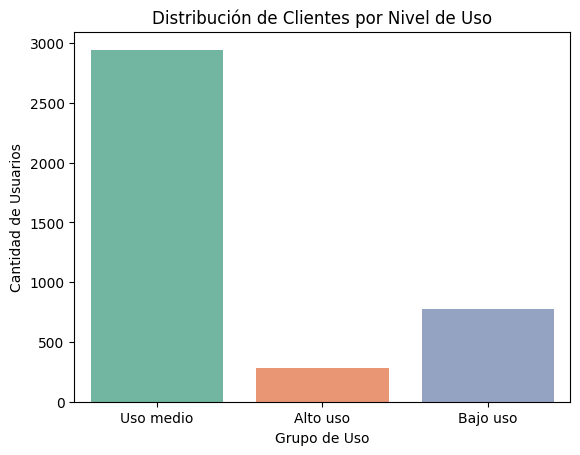

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='Set2')

# Agregar título y etiquetas a los ejes
plt.title('Distribución de Clientes por Nivel de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='Set3')

# Agregar título y etiquetas a los ejes
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()





---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores nulos en variables demográficas: La columna city presentó un 11.72% de datos faltantes (469 registros), lo que sugiere que este campo no está configurado como obligatorio durante el proceso de registro (onboarding).

- Valores nulos por diseño (MAR): En la tabla de uso, duration presentó un 55.19% de nulos (22,076 registros) y length un 44.74% (17,896 registros). Se comprobó que son nulos lógicos (Missing At Random) dependientes del tipo de servicio: los mensajes no tienen duración y las llamadas no tienen longitud de caracteres. Por otro lado, churn_date tuvo un 88.35% de nulos (3,534 registros), lo cual es una métrica de negocio positiva, ya que representa a los clientes que continúan activos.

- Sentinels y fechas imposibles: Se detectó el valor centinela "-999" en la columna age (corregido posteriormente con la mediana). Adicionalmente, la columna reg_date contenía 40 registros con el año futuro 2026, lo que indica un problema en la validación del sistema de captura.


🔍 **Segmentos por Edad**
- Los usuarios fueron segmentados en Jóvenes (< 30 años), Adultos (30 a 59 años) y Adultos Mayores (60 años o más).

- La distribución demográfica es sorprendentemente uniforme desde los 18 hasta los 80 años. No existe una brecha generacional en la adopción del servicio: tanto los clientes jóvenes como los adultos mayores adquieren los planes Básico y Premium en proporciones muy similares, sin un sesgo marcado por la edad.


📊 **Segmentos por Nivel de Uso**
- Se clasificó el comportamiento en Bajo uso (llamadas y mensajes < 5), Uso medio (llamadas y mensajes < 10) y Alto uso (resto de los casos).

- El comportamiento masivo de la base de clientes tiene una distribución asimétrica positiva (sesgada a la derecha). La gran mayoría de los usuarios se concentra en el espectro de Bajo y Medio uso, alcanzando sus picos máximos en 4 llamadas, 5 a 6 mensajes, y entre 10 y 30 minutos de consumo total.


➡️ Esto sugiere que ...
- Los segmentos más valiosos para ConnectaTel son el grupo de Alto uso y el 35.12% de clientes que ya pagan la suscripción Premium. Dentro del 64.88% de clientes con plan Básico, aquellos que caen en la categoría de Alto uso representan un potencial de ingresos (upselling) no aprovechado.

- Los valores extremos (outliers) detectados —clientes que superan los 60 minutos (llegando hasta 155), más de 10 llamadas o más de 11 mensajes— son legítimos. Reflejan la existencia de un segmento de heavy users (potenciales perfiles comerciales, pymes o trabajadores independientes) cuyo comportamiento intensivo es real y exige atención estratégica.

💡 **Recomendaciones**
- Estrategia de Upselling (Migración de Plan): Ejecutar una campaña dirigida exclusivamente a los clientes del plan Básico segmentados como "Alto uso" u outliers. Mostrarles mediante notificaciones que están cerca de sus límites operativos y ofrecerles beneficios exclusivos por migrar al plan Premium.

- Creación de un Plan Corporativo/Ilimitado: Dado el claro volumen de heavy users aislados en la cola superior de las gráficas de uso (más de 130 minutos o múltiples llamadas recurrentes), ConnectaTel debería evaluar lanzar un tercer nivel de servicio (Plan Ultra o Negocios) para monetizar mejor a este segmento que hace un uso intensivo de la red.

- Gobernanza de Datos: Implementar validaciones de entrada en el software (Front-end) de ConnectaTel para bloquear el ingreso de edades irreales (-999), impedir la selección de fechas futuras en el calendario de registro y hacer del campo city un requerimiento obligatorio para poder perfilar mejor las campañas regionales en el futuro.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`